# 📈 Polynomial Regression

## 🎯 Learning Objectives

After completing this notebook, you will be able to:

- Understand Polynomial Regression.
- Learn why Linear Regression sometimes fails.
- Understand polynomial features.
- Learn the mathematical intuition behind Polynomial Regression.
- Build and evaluate a Polynomial Regression model.
- Compare Linear Regression and Polynomial Regression.

## 📖 Introduction

Polynomial Regression is an extension of Linear Regression that models non-linear relationships between the independent and dependent variables.

Instead of fitting a straight line, it fits a curve to better represent the relationship in the data.

Even though it creates polynomial features, it is still considered a Linear Regression model because it remains linear in its coefficients.

## ❓ Why Polynomial Regression?

Simple Linear Regression assumes a straight-line relationship.

However, many real-world problems have curved relationships.

Examples:

- Employee Salary vs Position Level
- Population Growth
- Product Demand
- Temperature Changes
- Biological Growth

In such cases, a straight line cannot accurately model the data.

## 🌍 Real-Life Intuition

Suppose a company wants to estimate the salary of employees based on their position level.

As the position level increases:

Level 1 → ₹45,000

Level 5 → ₹110,000

Level 10 → ₹10,00,000

The salary does not increase at a constant rate.

Instead, it grows rapidly, forming a curved relationship.

Polynomial Regression can capture this non-linear pattern.

## ➗ Mathematical Equation

Simple Linear Regression:

ŷ = b₀ + b₁X

Polynomial Regression:

ŷ = b₀ + b₁X + b₂X² + b₃X³ + ... + bₙXⁿ

Where:

- ŷ = Predicted value
- X = Independent Variable
- b₀ = Intercept
- b₁, b₂, ... = Coefficients

## 📊 Polynomial Features

Original Feature:

X

Polynomial Features:

X

X²

X³

X⁴

...

These additional features allow the model to fit curved relationships.

## ✅ Advantages

- Captures non-linear relationships
- Easy to implement
- Works well for moderately curved data
- Flexible

## ❌ Disadvantages

- Can easily overfit
- Sensitive to outliers
- High-degree polynomials may perform poorly
- Difficult to interpret

## 🌍 Applications

- Salary Prediction
- Stock Trend Approximation
- Population Growth
- Sales Forecasting
- Engineering Problems

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

In [2]:
df = pd.read_csv(r"D:\Sanskruti\sanskruti document\Machine-Learning-From-Scratch\datasets\Position_Salaries.csv")

In [3]:
df.head()

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Position  10 non-null     object
 1   Level     10 non-null     int64 
 2   Salary    10 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 372.0+ bytes


In [5]:
X = df[["Level"]]

y = df["Salary"]

In [6]:
linear_model = LinearRegression()

linear_model.fit(X, y)

LinearRegression()

In [8]:
poly = PolynomialFeatures(degree=4)

X_poly = poly.fit_transform(X)

In [9]:
poly_model = LinearRegression()

poly_model.fit(X_poly, y)

LinearRegression()

In [10]:
linear_pred = linear_model.predict(X)

In [11]:
poly_pred = poly_model.predict(X_poly)

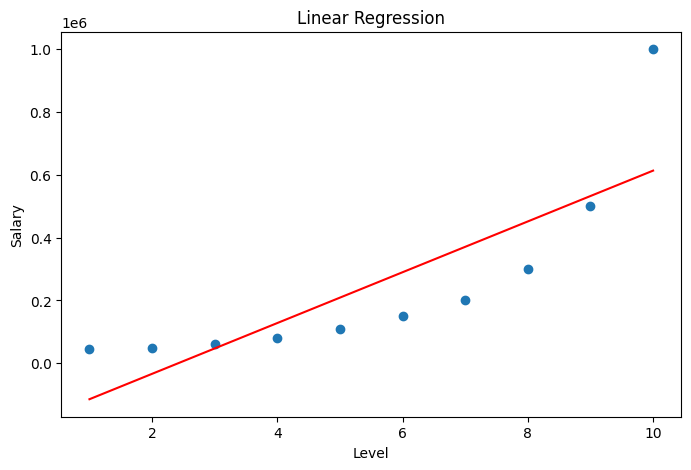

In [12]:
plt.figure(figsize=(8,5))

plt.scatter(X, y)

plt.plot(X, linear_pred, color="red")

plt.title("Linear Regression")

plt.xlabel("Level")

plt.ylabel("Salary")

plt.show()

C:\Users\Rushi\AppData\Local\Temp\ipykernel_35908\4246369630.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X.values), max(X.values), 0.1)
C:\Users\Rushi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


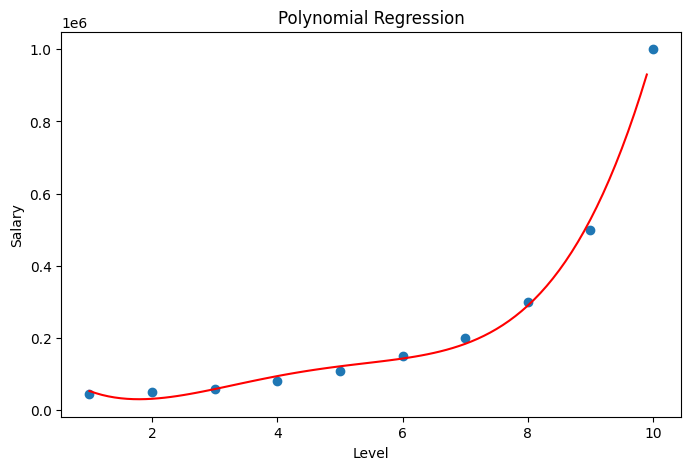

In [13]:
X_grid = np.arange(min(X.values), max(X.values), 0.1)

X_grid = X_grid.reshape(-1,1)

plt.figure(figsize=(8,5))

plt.scatter(X, y)

plt.plot(
    X_grid,
    poly_model.predict(poly.transform(X_grid)),
    color="red"
)

plt.title("Polynomial Regression")

plt.xlabel("Level")

plt.ylabel("Salary")

plt.show()

In [14]:
salary = poly_model.predict(poly.transform([[6.5]]))

print("Predicted Salary:", salary[0])

Predicted Salary: 158862.45265155006


C:\Users\Rushi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


## 📊 Choosing Polynomial Degree

Degree = 1 → Linear Regression

Degree = 2 → Slight Curve

Degree = 3 → More Flexible

Degree = 4 → Common Choice

Very High Degree → Overfitting

## ⚠️ Overfitting

Higher-degree polynomials may perfectly fit the training data but perform poorly on unseen data.

Always choose the degree carefully.

## ⚠️ Common Mistakes

- Using a very high degree
- Ignoring overfitting
- Forgetting to transform prediction data
- Not comparing with Linear Regression

## ✅ Best Practices

- Start with degree 2 or 3
- Compare different degrees
- Visualize the fitted curve
- Use cross-validation to choose the best degree

## 📝 Summary

Polynomial Regression extends Linear Regression by adding polynomial features. It enables the model to capture non-linear relationships while still using linear regression techniques.